In [ ]:
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from langchain_ollama import ChatOllama
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain.messages import RemoveMessage, HumanMessage, SystemMessage

In [11]:
llm = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
chat = ChatOllama(model="llama3", temperature=0.9)


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2136.72it/s]


In [12]:
def create_vector_store(model=llm):
    dummy = "dummy text"
    vector_store = FAISS.from_texts([dummy], model)
    dummy_id = list(vector_store.docstore._dict.keys())[0]
    vector_store.delete([dummy_id])
    return vector_store

vector_store = create_vector_store(llm)

def summarize_and_store(state: MessagesState):
    messages_to_archive = state["messages"][:4]
    
    # Fix 2: Convert the list of message objects into a single formatted string block
    formatted_history = ""
    for msg in messages_to_archive:
        speaker = "User" if isinstance(msg, HumanMessage) else "Assistant"
        formatted_history += f"{speaker}: {msg.content}\n"
    
    # Check if we already have past summaries in the store to refine
    all_docs = list(vector_store.docstore._dict.values())
    
    if all_docs:
        curr_summary_text = "\n".join([item.page_content for item in all_docs])
        # Fix 3: Added the missing 'f' for string interpolation
        prompt = SystemMessage(
            content=f"""You are a helpful assistant that summarizes conversation histories.
Create a concise summary that merges the new conversation snippet with the existing summary summary.

Existing Summary:
{curr_summary_text}"""
        )
    else:
        prompt = SystemMessage(
            content="Create a concise summary of the following conversation snippet focusing on key details."
        )
        
    prompt_to_give = [prompt] + [HumanMessage(content=f"Snippet to summarize:\n{formatted_history}")]
    response = chat.invoke(prompt_to_give)
    
    # Fix 4: Clean up old keys and store only the text content string
    all_ids = list(vector_store.docstore._dict.keys())
    if all_ids:
        vector_store.delete(all_ids)
        
    vector_store.add_texts([response.content])
    
    # Fix 5: Safely return RemoveMessage instances
    return {"messages": [RemoveMessage(id=msg.id) for msg in messages_to_archive if msg.id]}

def chat_node(state: MessagesState):
    query_message = state["messages"][-1]
    
    # Fix 6: Use semantic search instead of manual dict reading
    # This ensures we use the vector store for its actual purpose
    relevant_history = vector_store.similarity_search(query_message.content, k=1)
    
    if relevant_history:
        context = relevant_history[0].page_content
        system_prompt = SystemMessage(
            content=f"You are Lord Varys. Answer the question based on this summarized context from your annals:\n{context}"
        )
    else:
        system_prompt = SystemMessage(
            content="You are Lord Varys, Master of Whisperers. Answer the question based on your general knowledge."
        )
        
    prompt_to_give = [system_prompt] + state["messages"]
    response = chat.invoke(prompt_to_give)
    return {"messages": [response]}

def router(state: MessagesState) -> str:
    # If state contains 6 or more messages, trigger pruning
    if len(state["messages"]) >= 6:
        return "summarize_and_store"
    return "END"

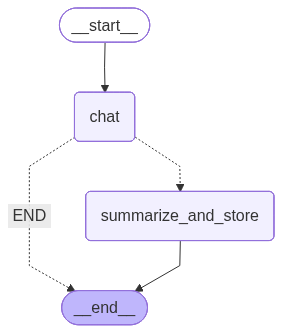

In [13]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat_node)
builder.add_node("summarize_and_store", summarize_and_store)

builder.add_edge(START, "chat")
builder.add_conditional_edges("chat", router, {
    "summarize_and_store": "summarize_and_store",
    "END": END
})
builder.add_edge("summarize_and_store", END)
graph = builder.compile(checkpointer=InMemorySaver())
graph